# Detection of Covid-19 Symptoms

Dataset URL: https://www.kaggle.com/datasets/iamhungundji/covid19-symptoms-checker

In [1]:
# Import libraries and modules
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import itertools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import models 
from tensorflow.keras.models import Sequential
from keras.utils.np_utils import to_categorical
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Data Import

In [2]:
# import dataset
df = pd.read_csv('COVID-19 Symptoms Checker.csv')

In [3]:
# checking first 5 rows of dataframe
df.head()

,Country,Age,Gender,Symptoms,Experiencing_Symptoms,Severity,Contact
0,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Yes
1,Italy,10-19,Female,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing","Pains,Nasal-Congestion,Runny-Nose",Moderate,No
2,Iran,20-24,Transgender,"Fever,Tiredness,Dry-Cough","Pains,Nasal-Congestion",Severe,Dont-Know
3,Republic of Korean,25-59,NaN,"Fever,Tiredness",Pains,None,NaN
4,France,60+,NaN,Fever,"Nasal-Congestion,Runny-Nose,Diarrhea",NaN,NaN


In [4]:
# count of rows and columns
df.shape

(16, 7)

### Data Generation from raw data

In [5]:
# finding total possible combination from raw data
country = len(df.Country.dropna().unique())
age = len(df.Age.dropna().unique())
gender = len(df.Gender.dropna().unique())
symptoms = len(df.Symptoms.dropna().unique())
esymptoms = len(df.Experiencing_Symptoms.dropna().unique())
severity = len(df.Severity.dropna().unique())
contact = len(df.Contact.dropna().unique())

print("Total Combination Possible: ",country * age * gender * symptoms * esymptoms * severity * contact)

Total Combination Possible:  316800


In [6]:
# generating records from raw data by finding total combination possible
columns = [df.Country.dropna().unique().tolist(),
          df.Age.dropna().unique().tolist(),
          df.Gender.dropna().unique().tolist(),
          df.Symptoms.dropna().unique().tolist(),
          df.Experiencing_Symptoms.dropna().unique().tolist(),
          df.Severity.dropna().unique().tolist(),
          df.Contact.dropna().unique().tolist()]

final_df= pd.DataFrame(list(itertools.product(*columns)), columns=df.columns)

In [7]:
# checking rows and columns counts in final dataset
final_df.shape

(316800, 7)

In [8]:
# checking first five rows of the final enerated dataset
final_df.head()

,Country,Age,Gender,Symptoms,Experiencing_Symptoms,Severity,Contact
0,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Yes
1,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,No
2,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Dont-Know
3,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,Yes
4,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,No


In [9]:
# creating dummy variable from symptoms column based on the symptoms
symptoms_list = final_df['Symptoms'].str.split(',')

from collections import Counter
symptoms_counter = Counter(([i for j in symptoms_list.tolist() for i in j]))

for symptom in symptoms_counter.keys():
    final_df[symptom] = 0
    final_df.loc[final_df['Symptoms'].str.contains(symptom), symptom] = 1

final_df.head()

,Country,Age,Gender,Symptoms,Experiencing_Symptoms,Severity,Contact,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton
0,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Yes,1,1,1,1,1,0
1,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,No,1,1,1,1,1,0
2,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Dont-Know,1,1,1,1,1,0
3,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,Yes,1,1,1,1,1,0
4,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,No,1,1,1,1,1,0


In [10]:
# creating dummy variable from Experiencing_Symptoms column based on the Experiencing_Symptoms

esymptoms_list = final_df['Experiencing_Symptoms'].str.split(',')

esymptoms_counter = Counter(([a for b in esymptoms_list.tolist() for a in b]))

for esymptom in esymptoms_counter.keys():
    final_df[esymptom] = 0
    final_df.loc[final_df['Experiencing_Symptoms'].str.contains(esymptom), esymptom] = 1

final_df.head()

,Country,Age,Gender,Symptoms,Experiencing_Symptoms,Severity,Contact,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,None_Experiencing
0,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Yes,1,1,1,1,1,0,1,1,1,1,0
1,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,No,1,1,1,1,1,0,1,1,1,1,0
2,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Dont-Know,1,1,1,1,1,0,1,1,1,1,0
3,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,Yes,1,1,1,1,1,0,1,1,1,1,0
4,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,No,1,1,1,1,1,0,1,1,1,1,0


In [11]:
final_df.columns

Index(['Country', 'Age', 'Gender', 'Symptoms', 'Experiencing_Symptoms',
       'Severity', 'Contact', 'Fever', 'Tiredness', 'Dry-Cough',
       'Difficulty-in-Breathing', 'Sore-Throat', 'None_Sympton', 'Pains',
       'Nasal-Congestion', 'Runny-Nose', 'Diarrhea', 'None_Experiencing'],
      dtype='object')

In [12]:
# drop irrelevant columns after extracting valuable informtion from existing columns 
# including symptoms, Experiencing_Symptoms, Country

final_df = final_df.drop(['Symptoms','Experiencing_Symptoms'],axis=1)
dummies = pd.get_dummies(final_df.drop('Country',axis=1))
dummies['Country'] = final_df['Country']
final_df = dummies
final_df.head()

,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,...,Gender_Male,Gender_Transgender,Severity_Mild,Severity_Moderate,Severity_None,Severity_Severe,Contact_Dont-Know,Contact_No,Contact_Yes,Country
0,1,1,1,1,1,0,1,1,1,1,...,1,0,1,0,0,0,0,0,1,China
1,1,1,1,1,1,0,1,1,1,1,...,1,0,1,0,0,0,0,1,0,China
2,1,1,1,1,1,0,1,1,1,1,...,1,0,1,0,0,0,1,0,0,China
3,1,1,1,1,1,0,1,1,1,1,...,1,0,0,1,0,0,0,0,1,China
4,1,1,1,1,1,0,1,1,1,1,...,1,0,0,1,0,0,0,1,0,China


### Data preprocessing of final data

In [13]:
# shape of dataframe after creating dummy variable
final_df.shape

(316800, 27)

In [14]:
# info of dataframe 
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316800 entries, 0 to 316799
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Fever                    316800 non-null  int64 
 1   Tiredness                316800 non-null  int64 
 2   Dry-Cough                316800 non-null  int64 
 3   Difficulty-in-Breathing  316800 non-null  int64 
 4   Sore-Throat              316800 non-null  int64 
 5   None_Sympton             316800 non-null  int64 
 6   Pains                    316800 non-null  int64 
 7   Nasal-Congestion         316800 non-null  int64 
 8   Runny-Nose               316800 non-null  int64 
 9   Diarrhea                 316800 non-null  int64 
 10  None_Experiencing        316800 non-null  int64 
 11  Age_0-9                  316800 non-null  uint8 
 12  Age_10-19                316800 non-null  uint8 
 13  Age_20-24                316800 non-null  uint8 
 14  Age_25-59           

In [15]:
# checking null values in final dataframe
final_df.isnull().sum()

Fever                      0
Tiredness                  0
Dry-Cough                  0
Difficulty-in-Breathing    0
Sore-Throat                0
None_Sympton               0
Pains                      0
Nasal-Congestion           0
Runny-Nose                 0
Diarrhea                   0
None_Experiencing          0
Age_0-9                    0
Age_10-19                  0
Age_20-24                  0
Age_25-59                  0
Age_60+                    0
Gender_Female              0
Gender_Male                0
Gender_Transgender         0
Severity_Mild              0
Severity_Moderate          0
Severity_None              0
Severity_Severe            0
Contact_Dont-Know          0
Contact_No                 0
Contact_Yes                0
Country                    0
dtype: int64

In [16]:
# count the number of items for each attribute

for i in final_df.columns:
    print('Attribute name:',i)
    print('-------------------')
    print(final_df[i].value_counts())
    print('-------------------')

Attribute name: Fever
-------------------
0    217800
1     99000
Name: Fever, dtype: int64
-------------------
Attribute name: Tiredness
-------------------
1    158400
0    158400
Name: Tiredness, dtype: int64
-------------------
Attribute name: Dry-Cough
-------------------
1    178200
0    138600
Name: Dry-Cough, dtype: int64
-------------------
Attribute name: Difficulty-in-Breathing
-------------------
1    158400
0    158400
Name: Difficulty-in-Breathing, dtype: int64
-------------------
Attribute name: Sore-Throat
-------------------
0    217800
1     99000
Name: Sore-Throat, dtype: int64
-------------------
Attribute name: None_Sympton
-------------------
0    297000
1     19800
Name: None_Sympton, dtype: int64
-------------------
Attribute name: Pains
-------------------
0    201600
1    115200
Name: Pains, dtype: int64
-------------------
Attribute name: Nasal-Congestion
-------------------
1    172800
0    144000
Name: Nasal-Congestion, dtype: int64
-------------------
Attr

### Extracting the target column

In [17]:
# filtering out all severity columns from the dataframe 
severity_columns = final_df.filter(like='Severity_').columns

In [18]:
# encoding values in severity columns

final_df['Severity_None'].replace({1:'None',0:'No'},inplace =True)
final_df['Severity_Mild'].replace({1:'Mild',0:'No'},inplace =True)
final_df['Severity_Moderate'].replace({1:'Moderate',0:'No'},inplace =True)
final_df['Severity_Severe'].replace({1:'Severe',0:'No'},inplace =True)

In [19]:
final_df['Condition']=final_df[severity_columns].values.tolist()

In [20]:
# checking values within condition column
final_df['Condition']

0             [Mild, No, No, No]
1             [Mild, No, No, No]
2             [Mild, No, No, No]
3         [No, Moderate, No, No]
4         [No, Moderate, No, No]
                   ...          
316795      [No, No, No, Severe]
316796      [No, No, No, Severe]
316797        [No, No, None, No]
316798        [No, No, None, No]
316799        [No, No, None, No]
Name: Condition, Length: 316800, dtype: object

In [21]:
# keeping only relevant data in condition column
def remove(lis):
    lis = set(lis) 
    lis.discard("No")
    final = ''.join(lis)
    return final


final_df['Condition'] = final_df['Condition'].apply(remove)

In [22]:
# checking condition column after data processing
final_df['Condition']

0             Mild
1             Mild
2             Mild
3         Moderate
4         Moderate
            ...   
316795      Severe
316796      Severe
316797        None
316798        None
316799        None
Name: Condition, Length: 316800, dtype: object

In [23]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


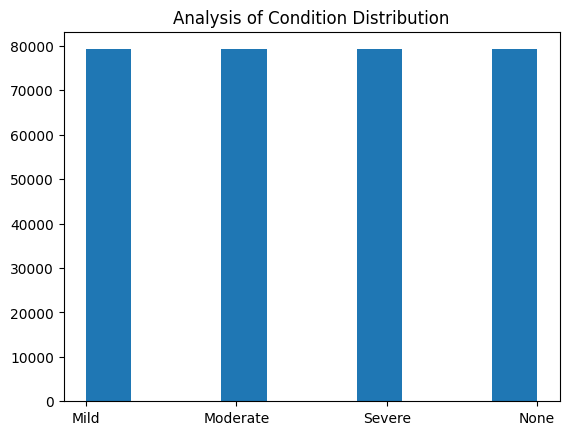

In [24]:
import seaborn as sns
import plotly.express as px


plt.hist(final_df['Condition'])
plt.title('Analysis of Condition Distribution')
plt.show()

# Extracting the age, gender, and contact columns

In [25]:
# filtering out age, gender and contact columns
age_columns = final_df.filter(like='Age_').columns
gender_columns = final_df.filter(like='Gender_').columns
contact_columns = final_df.filter(like='Contact_').columns

In [26]:
# finding no risk parameters based on the data avaliable for age, gender and contact column

No_risk_age = final_df.groupby(['Severity_None'])[age_columns].sum()
No_risk_gender = final_df.groupby(['Severity_None'])[gender_columns].sum()
No_risk_contact = final_df.groupby(['Severity_None'])[contact_columns].sum()

In [27]:
# finding low risk parameters based on the data avaliable for age, gender and contact column

Low_risk_age = final_df.groupby(['Severity_Mild'])[age_columns].sum()
Low_risk_gender = final_df.groupby(['Severity_Mild'])[gender_columns].sum()
Low_risk_contact = final_df.groupby(['Severity_Mild'])[contact_columns].sum()

In [28]:
# finding moderate risk parameters based on the data avaliable for age, gender and contact column

Moderate_risk_age = final_df.groupby(['Severity_Moderate'])[age_columns].sum()
Moderate_risk_gender = final_df.groupby(['Severity_Moderate'])[gender_columns].sum()
Moderate_risk_contact = final_df.groupby(['Severity_Moderate'])[contact_columns].sum()

In [29]:
# finding severe risk parameters based on the data avaliable for age, gender and contact column

Severe_risk_age = final_df.groupby(['Severity_Severe'])[age_columns].sum()
Severe_risk_gender = final_df.groupby(['Severity_Severe'])[gender_columns].sum()
Severe_risk_contact = final_df.groupby(['Severity_Severe'])[contact_columns].sum()

In [30]:
# drop severity column after extracting valuable information from this
final_df.drop(severity_columns,axis=1,inplace=True)

In [31]:
# first five rows after data processing 

final_df.head()

,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,...,Age_25-59,Age_60+,Gender_Female,Gender_Male,Gender_Transgender,Contact_Dont-Know,Contact_No,Contact_Yes,Country,Condition
0,1,1,1,1,1,0,1,1,1,1,...,0,0,0,1,0,0,0,1,China,Mild
1,1,1,1,1,1,0,1,1,1,1,...,0,0,0,1,0,0,1,0,China,Mild
2,1,1,1,1,1,0,1,1,1,1,...,0,0,0,1,0,1,0,0,China,Mild
3,1,1,1,1,1,0,1,1,1,1,...,0,0,0,1,0,0,0,1,China,Moderate
4,1,1,1,1,1,0,1,1,1,1,...,0,0,0,1,0,0,1,0,China,Moderate


In [32]:
# label encoder processing in final dataframe
le = preprocessing.LabelEncoder()
final_df['Condition'] = le.fit_transform(final_df['Condition'])

In [33]:
# checking all the columns avaliable in final dataframe
final_df.columns

Index(['Fever', 'Tiredness', 'Dry-Cough', 'Difficulty-in-Breathing',
       'Sore-Throat', 'None_Sympton', 'Pains', 'Nasal-Congestion',
       'Runny-Nose', 'Diarrhea', 'None_Experiencing', 'Age_0-9', 'Age_10-19',
       'Age_20-24', 'Age_25-59', 'Age_60+', 'Gender_Female', 'Gender_Male',
       'Gender_Transgender', 'Contact_Dont-Know', 'Contact_No', 'Contact_Yes',
       'Country', 'Condition'],
      dtype='object')

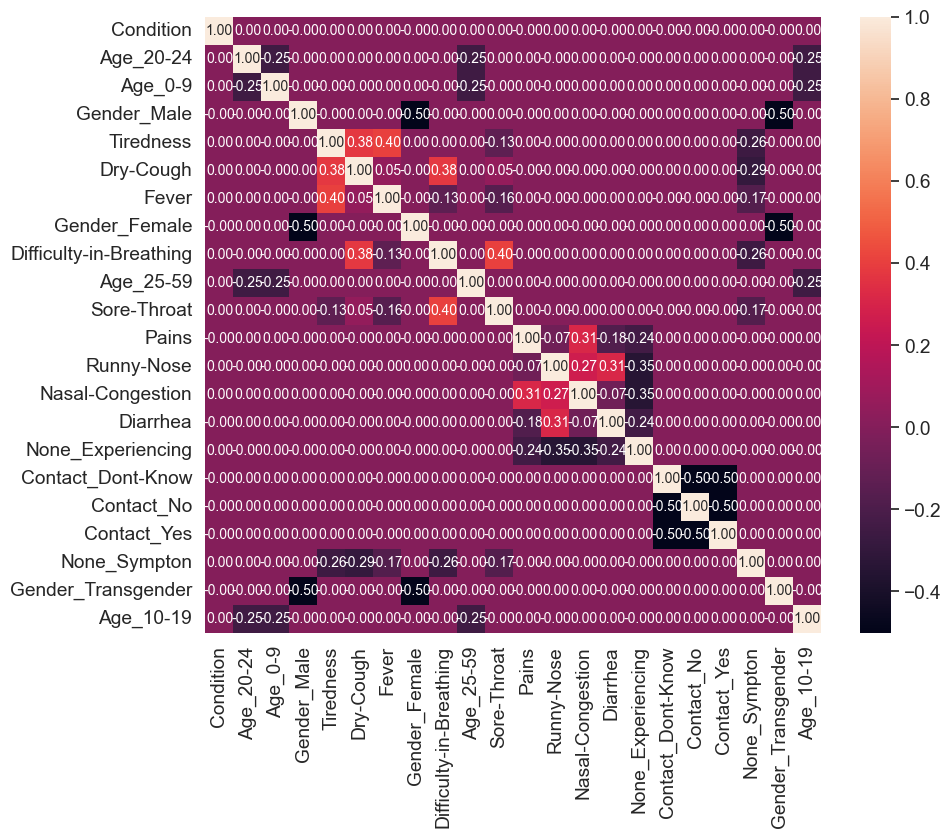

In [34]:
# correlation of the variables in dataframe
from pylab import rcParams
rcParams['figure.figsize'] = 10, 8
corrmat = final_df.corr()
k = 22
cols = corrmat.nlargest(k, 'Condition')['Condition'].index
cm = np.corrcoef(final_df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
                 annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [35]:
# seperating X and y for model training 
X= final_df.drop(['Condition', 'Age_0-9', 'Age_10-19', 'Age_20-24', 'Age_25-59', 'Age_25-59', 'Age_60+', 
                  'Gender_Female', 'Gender_Male', 'Gender_Transgender', 'Contact_Dont-Know', 
                  'Contact_No', 'Contact_Yes', 'Country'],axis=1)

y= final_df['Condition']

In [36]:
# checking X
X

,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,None_Experiencing
0,1,1,1,1,1,0,1,1,1,1,0
1,1,1,1,1,1,0,1,1,1,1,0
2,1,1,1,1,1,0,1,1,1,1,0
3,1,1,1,1,1,0,1,1,1,1,0
4,1,1,1,1,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
316795,0,0,0,0,0,1,0,0,0,0,1
316796,0,0,0,0,0,1,0,0,0,0,1
316797,0,0,0,0,0,1,0,0,0,0,1
316798,0,0,0,0,0,1,0,0,0,0,1


In [37]:
# checking y
y

0         0
1         0
2         0
3         1
4         1
         ..
316795    3
316796    3
316797    2
316798    2
316799    2
Name: Condition, Length: 316800, dtype: int64

In [38]:
# train test split from X and y for model training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# checking sample of X_train
X_train.sample(frac=1)

,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,None_Experiencing
169326,1,1,1,0,0,0,0,0,1,0,0
274982,1,1,0,0,0,0,1,1,0,0,0
191231,0,1,0,0,0,0,0,0,1,1,0
282356,0,0,1,0,0,0,1,1,1,1,0
149283,0,0,1,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
100061,0,1,1,1,0,0,1,1,1,1,0
31397,0,0,0,1,0,0,0,0,0,1,0
174405,0,0,1,1,1,0,1,1,0,0,0
249296,1,1,1,1,1,0,0,1,0,0,0


### Model development

In [40]:
# rows and column counts of X_train
X_train.shape

(253440, 11)

In [41]:
# transforming y_train data into categorical format where class number is 4
y_train = to_categorical(y_train, num_classes = 4)
y_train.shape

(253440, 4)

In [42]:
# checking y_train after categorical transformation
y_train

array([[0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.]], dtype=float32)

In [43]:
# transforming y_test data into categorical format where class number is 4

y_test = to_categorical(y_test, num_classes=4)
y_test.shape

(63360, 4)

In [44]:
# CNN model configuration
model=keras.models.Sequential()
model.add(keras.layers.Dense(units= 32, input_shape=(11,),activation='relu'))
model.add(keras.layers.Dense(units= 64,activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(units= 128,activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(units= 32,activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.1))
model.add(keras.layers.Dense(units= 16,activation='relu'))
model.add(keras.layers.Dense(units= 8,activation='relu'))
model.add(keras.layers.Dense(4,activation='softmax'))

2023-09-21 11:53:27.425699: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [45]:
# summary of configured model
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                384       
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout (Dropout)           (None, 128)               0

In [46]:
# compilation of model using optimizer, loss and metrics
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [49]:
# fit model using train and validation data where epochs is 25
history = model.fit(X_train, y_train, epochs=25, batch_size=64, verbose=2, validation_data=(X_test, y_test))

Epoch 1/25
3960/3960 - 7s - loss: 1.3864 - accuracy: 0.2497 - val_loss: 1.3863 - val_accuracy: 0.2481 - 7s/epoch - 2ms/step
Epoch 2/25
3960/3960 - 7s - loss: 1.3864 - accuracy: 0.2505 - val_loss: 1.3863 - val_accuracy: 0.2487 - 7s/epoch - 2ms/step
Epoch 3/25
3960/3960 - 6s - loss: 1.3864 - accuracy: 0.2506 - val_loss: 1.3863 - val_accuracy: 0.2521 - 6s/epoch - 2ms/step
Epoch 4/25
3960/3960 - 6s - loss: 1.3864 - accuracy: 0.2486 - val_loss: 1.3863 - val_accuracy: 0.2481 - 6s/epoch - 2ms/step
Epoch 5/25
3960/3960 - 6s - loss: 1.3864 - accuracy: 0.2491 - val_loss: 1.3865 - val_accuracy: 0.2481 - 6s/epoch - 2ms/step
Epoch 6/25
3960/3960 - 6s - loss: 1.3864 - accuracy: 0.2498 - val_loss: 1.3863 - val_accuracy: 0.2511 - 6s/epoch - 2ms/step
Epoch 7/25
3960/3960 - 6s - loss: 1.3864 - accuracy: 0.2499 - val_loss: 1.3863 - val_accuracy: 0.2481 - 6s/epoch - 2ms/step
Epoch 8/25
3960/3960 - 6s - loss: 1.3863 - accuracy: 0.2505 - val_loss: 1.3863 - val_accuracy: 0.2487 - 6s/epoch - 2ms/step
Epoch 9/

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


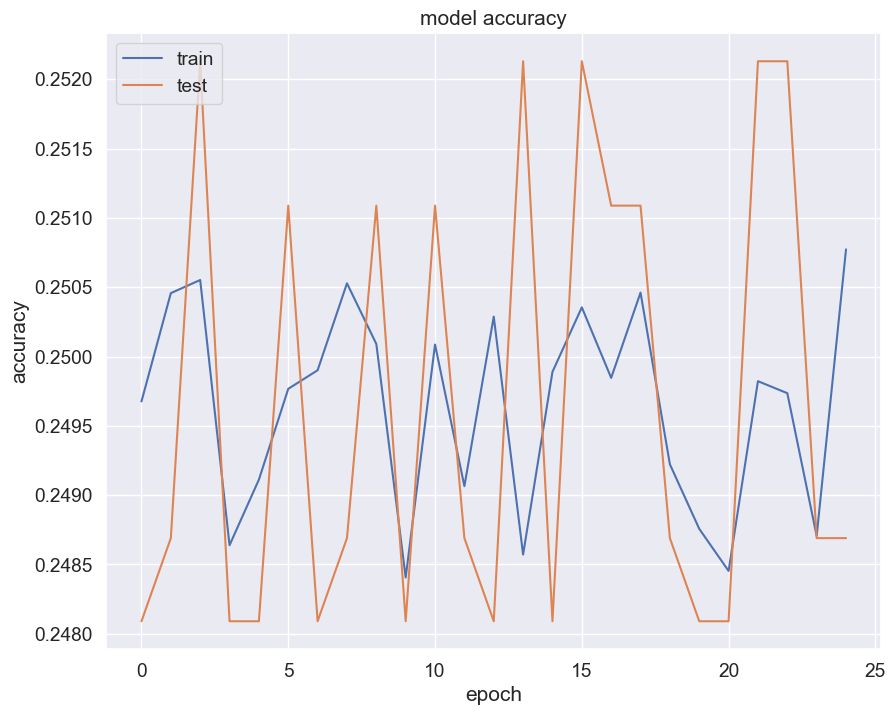

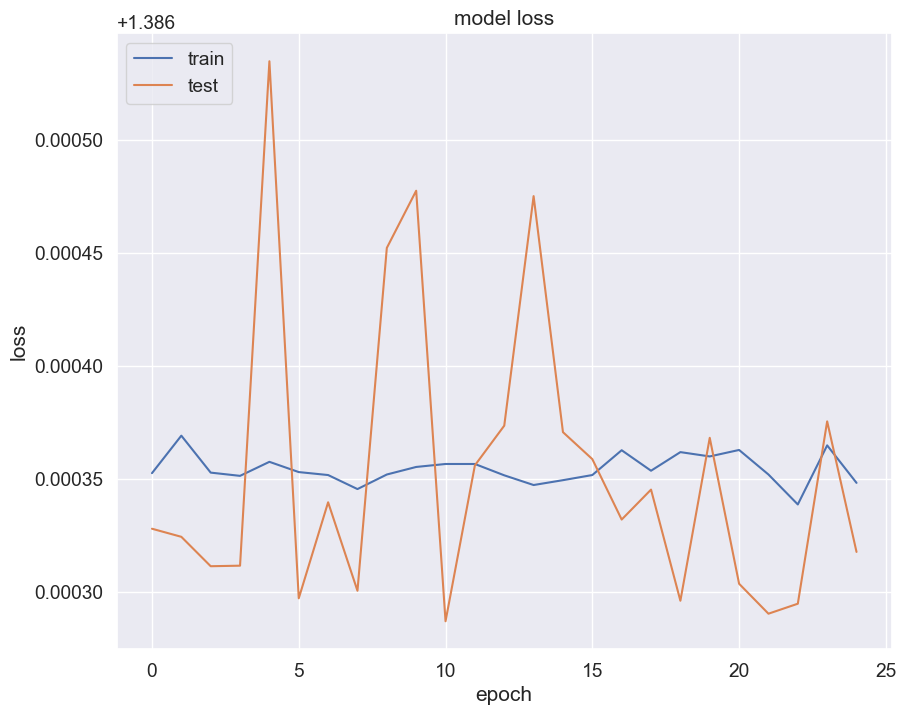

In [50]:
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Classification Model

In [51]:
# importing clean data for classification model
data = pd.read_csv('Cleaned-Data.csv')

In [52]:
# checking imported dataframe
data

,Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,Diarrhea,...,Gender_Male,Gender_Transgender,Severity_Mild,Severity_Moderate,Severity_None,Severity_Severe,Contact_Dont-Know,Contact_No,Contact_Yes,Country
0,1,1,1,1,1,0,1,1,1,1,...,1,0,1,0,0,0,0,0,1,China
1,1,1,1,1,1,0,1,1,1,1,...,1,0,1,0,0,0,0,1,0,China
2,1,1,1,1,1,0,1,1,1,1,...,1,0,1,0,0,0,1,0,0,China
3,1,1,1,1,1,0,1,1,1,1,...,1,0,0,1,0,0,0,0,1,China
4,1,1,1,1,1,0,1,1,1,1,...,1,0,0,1,0,0,0,1,0,China
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316795,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,0,1,0,Other
316796,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,1,0,0,Other
316797,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,0,1,Other
316798,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,1,0,Other


In [53]:
# Target features
y = data[['Severity_Mild','Severity_Moderate','Severity_None','Severity_Severe']]

# Input features
X = data.drop(['Severity_Mild','Severity_Moderate','Severity_None','Severity_Severe'], axis=1)

In [54]:
# transforming X and y into array using make_blobs for model training
X, y = make_blobs(n_samples=316800, n_features=26, centers=4,
    random_state=0)

# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, 
                                                    random_state=123,
                                                    stratify=y)

In [55]:
# checking X_train dataframe
X_train

array([[-6.07930653,  8.79582523,  2.42325853, ..., -2.17110936,
         0.28932354, -1.12746895],
       [-7.34688677,  8.77429808,  0.41465004, ..., -3.2248543 ,
         0.96941765, -2.39557874],
       [ 0.7175904 ,  5.45703424,  3.14499913, ...,  5.22057053,
        -7.14725143,  2.6801416 ],
       ...,
       [-5.18182932,  9.03889656, -1.02443238, ..., -2.63037148,
         1.27561773, -2.81671466],
       [ 1.84929393,  4.15679509,  0.67746614, ...,  4.68552135,
        -7.94272422,  2.15687116],
       [-6.26858568,  8.35372615,  0.45247664, ..., -3.12801975,
         2.24036973, -1.70199672]])

In [56]:
# checking X_test dataframe
X_test

array([[-4.69455749, -5.76717217, -2.93369   , ..., -4.21158745,
         5.09411782,  9.71967971],
       [-6.60256817,  9.40913498,  0.79993291, ..., -3.44856754,
         0.53519989, -0.1307903 ],
       [ 7.32315217, -7.66857442, -7.72342621, ..., -7.49925844,
        -4.99013814, -6.96741331],
       ...,
       [-4.94389899, -7.64979231, -3.36617788, ..., -5.29550704,
         3.61204651,  9.63583691],
       [ 1.55801177,  2.62394015,  1.98967376, ...,  4.63044154,
        -7.98304588,  3.99760945],
       [ 1.5343055 ,  2.79757923,  2.92223361, ...,  4.86635394,
        -8.62792083,  2.11211592]])

In [57]:
# checking y_train dataframe
y_train

array([1, 1, 0, ..., 1, 0, 1])

In [58]:
# checking y_test dataframe
y_test

array([3, 1, 2, ..., 3, 0, 0])

## Random Forest Classifier

In [59]:
#RandomForest model configuration using estimator 20, depth 10, sample split 2 
RandomForest = RandomForestClassifier(n_estimators=20, max_depth=10,
    min_samples_split=2, random_state=0)

# finding score of Random Forest using cross_val_score where cross_val parameter is 5
scores = cross_val_score(RandomForest, X, y, cv=5)

# print mean score
print('RandomForest scores.mean: ',scores.mean() )

# fit the model using X_train and y_train
RandomForest=RandomForest.fit(X_train, y_train)

# predict data from trained Random Forest model using X_test data
predRandomForest = RandomForest.predict(X_test)

# print r2_score of Random Forest model based on actual and predicted data
print('RandomForest r2_score: ', r2_score(y_test, predRandomForest))

RandomForest scores.mean:  1.0
RandomForest r2_score:  1.0


In [60]:
y_test.shape

(63360,)

In [61]:
from sklearn.metrics import classification_report, confusion_matrix

# classification report of Random Forest model
print('Classification report of Random Forest model\n\n',classification_report(y_test,predRandomForest))

Classification report of Random Forest model

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15840
           1       1.00      1.00      1.00     15840
           2       1.00      1.00      1.00     15840
           3       1.00      1.00      1.00     15840

    accuracy                           1.00     63360
   macro avg       1.00      1.00      1.00     63360
weighted avg       1.00      1.00      1.00     63360



In [66]:
# confusion report of Random Forest model
print('Confusion report of Random Forest model\n\n',confusion_matrix(y_test,predRandomForest))

Confusion report of Random Forest model

 [[15840     0     0     0]
 [    0 15840     0     0]
 [    0     0 15840     0]
 [    0     0     0 15840]]


In [73]:
X_train.shape

(253440, 26)

In [74]:
y_train.shape

(253440,)

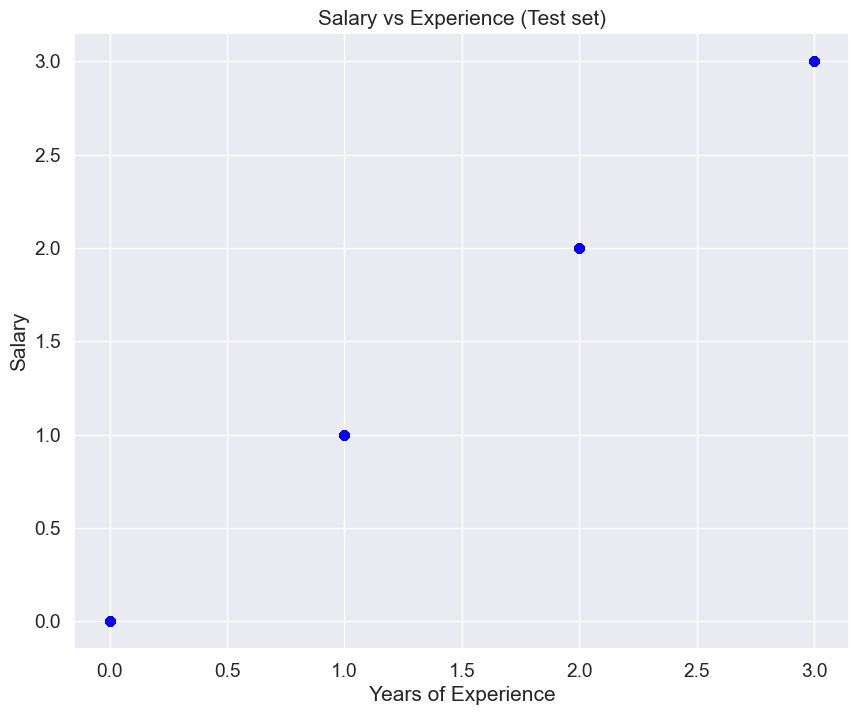

In [80]:
# plot original and predicted data points from test set
plt.scatter(y_test, predRandomForest, color = 'blue')
plt.title('Actual vs predicted data points (Test set)')
plt.xlabel('Actual Severity label')
plt.ylabel('Predicted Severity label')
plt.show()

As the model outcome is 100% accuracte, there is no difference between actual and predicted data points

## Decision Tree Classifier

In [81]:
# DecisionTree model configuration using depth 10, sample split 2 
DecisionTree = DecisionTreeClassifier(max_depth=10, min_samples_split=2,
    random_state=0)

# finding score of Decision Tree using cross_val_score where cross_val parameter is 5
scores = cross_val_score(DecisionTree, X, y, cv=5)

# print mean score
print('DecisionTree scores.mean: ', scores.mean())

# fit the model using X_train and y_train
DecisionTree = DecisionTree.fit(X_train, y_train)

# predict data from trained Decision Tree model using X_test data
predDecisionTree = DecisionTree.predict(X_test)

# print r2_score of Decision Tree model based on actual and predicted data
print('DecisionTree r2_score: ',r2_score(y_test, predDecisionTree))

DecisionTree scores.mean:  1.0
DecisionTree r2_score:  1.0


In [82]:
# classification report of Decision Tree model
print('Classification report of Decision Tree model\n\n',classification_report(y_test,predDecisionTree))

Classification report of Decision Tree model

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     15840
           1       1.00      1.00      1.00     15840
           2       1.00      1.00      1.00     15840
           3       1.00      1.00      1.00     15840

    accuracy                           1.00     63360
   macro avg       1.00      1.00      1.00     63360
weighted avg       1.00      1.00      1.00     63360



In [83]:
# confusion report of Decision Tree model
print('Confusion report of Decision Tree model\n\n',confusion_matrix(y_test,predDecisionTree))

Confusion report of Decision Tree model

 [[15840     0     0     0]
 [    0 15840     0     0]
 [    0     0 15840     0]
 [    0     0     0 15840]]


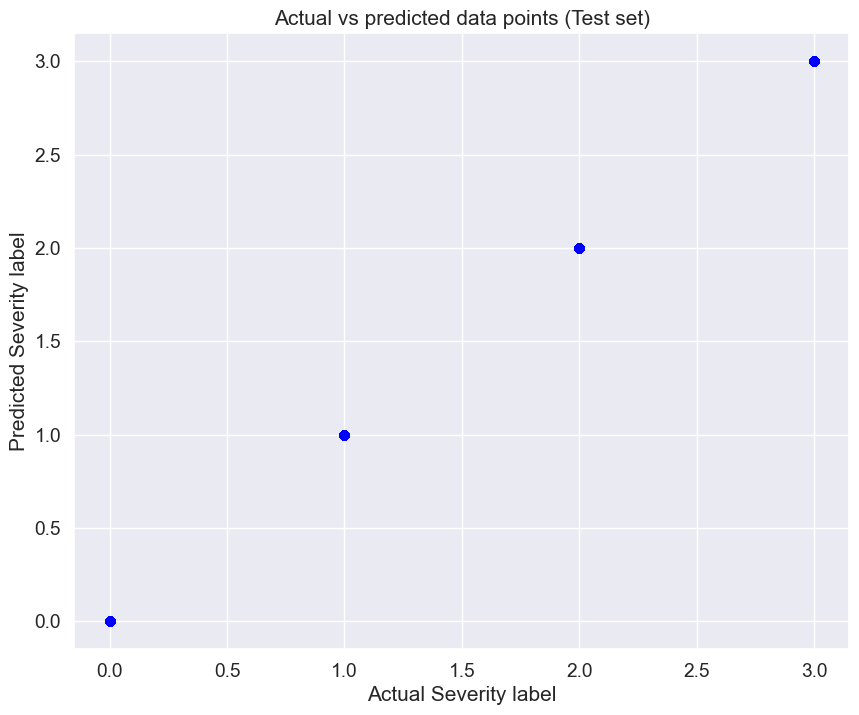

In [84]:
# plot original and predicted data points from test set
plt.scatter(y_test, predDecisionTree, color = 'blue')
plt.title('Actual vs predicted data points (Test set)')
plt.xlabel('Actual Severity label')
plt.ylabel('Predicted Severity label')
plt.show()

As the model outcome is 100% accuracte, there is no difference between actual and predicted data points

Summary: Neural network model shows less compatibility against predicting covid-19 symptoms, whereas decision tree and random forest classifier shows the best performance in this scenario. 